<a href="https://colab.research.google.com/github/sergeyarefjev/study/blob/main/ml/neural_network_learn_ff/Neural_Network.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Задание 4.1 - Нейронные сети

В этом задании вы реализуете и натренируете настоящую нейроную сеть своими руками!

В некотором смысле это будет расширением прошлого задания - нам нужно просто составить несколько линейных классификаторов вместе!

<img src="https://i.redd.it/n9fgba8b0qr01.png" alt="Stack_more_layers" width="400px"/>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

#%load_ext autoreload
#%autoreload 2

In [ ]:
from dataset import load_svhn, random_split_train_val
from gradient_check import check_layer_gradient, check_layer_param_gradient, check_model_gradient
from layers import FullyConnectedLayer, ReLULayer
from model import TwoLayerNet
from trainer import Trainer, Dataset
from optim import SGD, MomentumSGD
from metrics import multiclass_accuracy

In [ ]:
!mkdir data
!cd data
!wget -c http://ufldl.stanford.edu/housenumbers/train_32x32.mat http://ufldl.stanford.edu/housenumbers/test_32x32.mat

--2025-10-06 08:47:57--  http://ufldl.stanford.edu/housenumbers/train_32x32.mat
Resolving ufldl.stanford.edu (ufldl.stanford.edu)... 171.64.68.10
Connecting to ufldl.stanford.edu (ufldl.stanford.edu)|171.64.68.10|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 182040794 (174M) [text/plain]
Saving to: ‘train_32x32.mat’

train_32x32.mat     100%[===================>] 173.61M  18.3MB/s    in 11s     

2025-10-06 08:48:08 (16.2 MB/s) - ‘train_32x32.mat’ saved [182040794/182040794]

--2025-10-06 08:48:08--  http://ufldl.stanford.edu/housenumbers/test_32x32.mat
Reusing existing connection to ufldl.stanford.edu:80.
HTTP request sent, awaiting response... 200 OK
Length: 64275384 (61M) [text/plain]
Saving to: ‘test_32x32.mat’

test_32x32.mat      100%[===================>]  61.30M  17.9MB/s    in 3.4s    

2025-10-06 08:48:11 (17.9 MB/s) - ‘test_32x32.mat’ saved [64275384/64275384]

FINISHED --2025-10-06 08:48:11--
Total wall clock time: 14s
Downloaded: 2 files, 235M in

# Загружаем данные

И разделяем их на training и validation.

In [ ]:
def prepare_for_neural_network(train_X, test_X):
    train_flat = train_X.reshape(train_X.shape[0], -1).astype(np.float64) / 255.0
    test_flat = test_X.reshape(test_X.shape[0], -1).astype(np.float64) / 255.0

    # Subtract mean
    mean_image = np.mean(train_flat, axis = 0)
    train_flat -= mean_image
    test_flat -= mean_image

    return train_flat, test_flat

train_X, train_y, test_X, test_y = load_svhn("", max_train=10000, max_test=1000)
train_X, test_X = prepare_for_neural_network(train_X, test_X)
# Split train into train and val
train_X, train_y, val_X, val_y = random_split_train_val(train_X, train_y, num_val = 1000)

# Как всегда, начинаем с кирпичиков

Мы будем реализовывать необходимые нам слои по очереди. Каждый слой должен реализовать:
- прямой проход (forward pass), который генерирует выход слоя по входу и запоминает необходимые данные
- обратный проход (backward pass), который получает градиент по выходу слоя и вычисляет градиент по входу и по параметрам

Начнем с ReLU, у которого параметров нет.

In [ ]:
import numpy as np


def check_gradient(f, x, delta=1e-5, tol = 1e-4):
    '''
    Checks the implementation of analytical gradient by comparing
    it to numerical gradient using two-point formula

    Arguments:
      f: function that receives x and computes value and gradient
      x: np array, initial point where gradient is checked
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient

    Return:
      bool indicating whether gradients match or not
    '''

    assert isinstance(x, np.ndarray)
    assert x.dtype == np.float64

    orig_x = x.copy()
    fx, analytic_grad = f(x)
    assert np.all(np.isclose(orig_x, x, tol)), "Functions shouldn't modify input variables"

    assert analytic_grad.shape == x.shape
    analytic_grad = analytic_grad.copy()

    # We will go through every dimension of x and compute numeric
    # derivative for it
    it = np.nditer(x, flags=['multi_index'], op_flags=['readwrite'])
    while not it.finished:
        ix = it.multi_index
        analytic_grad_at_ix = analytic_grad[ix]
        h = delta
        x[ix] += h
        f_1 = f(x)
        x[ix] -= 2 * h
        f_2 = f(x)
        x[ix] += h
        numeric_grad_at_ix = (f_1[0] - f_2[0]) / (2 * h)

        if not np.isclose(numeric_grad_at_ix, analytic_grad_at_ix, tol):
            print(f"Gradients are different at {ix}. Analytic: {analytic_grad_at_ix}, Numeric: {numeric_grad_at_ix}")
            return False

        it.iternext()

    print("Gradient check passed!")
    return True


def check_layer_gradient(layer, x, delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the input and output of a layer

    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient

    Returns:
      bool indicating whether gradients match or not
    """
    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(x):
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        grad = layer.backward(d_out)
        return loss, grad

    return check_gradient(helper_func, x, delta, tol)


def check_layer_param_gradient(layer, x,
                               param_name,
                               delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for the parameter of the layer

    Arguments:
      layer: neural network layer, with forward and backward functions
      x: starting point for layer input
      param_name: name of the parameter
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient

    Returns:
      bool indicating whether gradients match or not
    """
    param = layer.params()[param_name]
    initial_w = param.value

    output = layer.forward(x)
    output_weight = np.random.randn(*output.shape)

    def helper_func(w):
        param.value = w
        output = layer.forward(x)
        loss = np.sum(output * output_weight)
        d_out = np.ones_like(output) * output_weight
        layer.backward(d_out)
        grad = param.grad
        return loss, grad

    return check_gradient(helper_func, initial_w, delta, tol)


def check_model_gradient(model, X, y,
                         delta=1e-5, tol=1e-4):
    """
    Checks gradient correctness for all model parameters

    Arguments:
      model: neural network model with compute_loss_and_gradients
      X: batch of input data
      y: batch of labels
      delta: step to compute numerical gradient
      tol: tolerance for comparing numerical and analytical gradient

    Returns:
      bool indicating whether gradients match or not
    """
    params = model.params()

    for param_key in params:
        print("Checking gradient for %s" % param_key)
        param = params[param_key]
        initial_w = param.value

        def helper_func(w):
            param.value = w
            loss = model.compute_loss_and_gradients(X, y)
            grad = param.grad
            return loss, grad

        if not check_gradient(helper_func, initial_w, delta, tol):
            return False

    return True




In [ ]:

class ReLULayer:
    def __init__(self):
        pass

    def forward(self, X):
        self.mask = np.where(X > 0, 1, 0)
        return np.where(X > 0, X, 0)

    def backward(self, d_out):
        """
        Backward pass

        Arguments:
        d_out, np array (batch_size, num_features) - gradient
           of loss function with respect to output

        Returns:
        d_result: np array (batch_size, num_features) - gradient
          with respect to input
        """
        d_result = self.mask * d_out
        return d_result

    def params(self):
        # ReLU Doesn't have any parameters
        return {}



In [ ]:
# TODO: Implement ReLULayer layer in layers.py
# Note: you'll need to copy implementation of the gradient_check function from the previous assignment

X = np.array([[1,-2,3],
              [-1, 2, 0.1]
              ])
relu = ReLULayer()
assert check_layer_gradient(ReLULayer(), X)

Gradient check passed!


А теперь реализуем полносвязный слой (fully connected layer), у которого будет два массива параметров: W (weights) и B (bias).

Все параметры наши слои будут использовать для параметров специальный класс `Param`, в котором будут храниться значения параметров и градиенты этих параметров, вычисляемые во время обратного прохода.

Это даст возможность аккумулировать (суммировать) градиенты из разных частей функции потерь, например, из cross-entropy loss и regularization loss.

In [ ]:
class Param:
    """
    Trainable parameter of the model
    Captures both parameter value and the gradient
    """

    def __init__(self, value):
        self.value = value
        self.grad = np.zeros_like(value)


In [ ]:
class FullyConnectedLayer:
    def __init__(self, n_input, n_output):
        self.W = Param(0.0001 * np.random.randn(n_input, n_output))
        self.B = Param(0.0001 * np.random.randn(1, n_output))
        self.X = None

    def forward(self, X):
        self.X = X
        return X @ self.W.value + self.B.value

    def backward(self, d_out):
        """
        Backward pass
        Computes gradient with respect to input and
        accumulates gradients within self.W and self.B

        Arguments:
        d_out, np array (batch_size, n_output) - gradient
           of loss function with respect to output

        Returns:
        d_result: np array (batch_size, n_input) - gradient
          with respect to input
        """
        self.W.grad = self.X.T @ d_out
        self.B.grad = np.sum(d_out, axis=0, keepdims=True)
        d_input = d_out @ self.W.value.T

        return d_input

    def params(self):
        return {'W': self.W, 'B': self.B}


In [ ]:
# TODO: Implement FullyConnected layer forward and backward methods
assert check_layer_gradient(FullyConnectedLayer(3, 4), X)
# TODO: Implement storing gradients for W and B
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'W')
assert check_layer_param_gradient(FullyConnectedLayer(3, 4), X, 'B')

Gradient check passed!
Gradient check passed!
Gradient check passed!


## Создаем нейронную сеть

Теперь мы реализуем простейшую нейронную сеть с двумя полносвязным слоями и нелинейностью ReLU. Реализуйте функцию `compute_loss_and_gradients`, она должна запустить прямой и обратный проход через оба слоя для вычисления градиентов.

Не забудьте реализовать очистку градиентов в начале функции.

In [ ]:
def softmax(predictions):
    '''
    Computes probabilities from scores

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output

    Returns:
      probs, np array of the same shape as predictions -
        probability for every class, 0..1
    '''
    # TODO implement softmax
    # Your final implementation shouldn't have any loops
    predictions_new = predictions.copy()
    predictions_new -= np.max(predictions_new, axis=1, keepdims=True)
    prob = np.exp(predictions_new) / (np.sum(np.exp(predictions_new), axis=1, keepdims=True))
   # raise Exception("Not implemented!")
    return prob

def cross_entropy_loss(probs, target_index):
    '''
    Computes cross-entropy loss

    Arguments:
      probs, np array, shape is either (N) or (batch_size, N) -
        probabilities for every class
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss: single value
    '''
    # TODO implement cross-entropy
    # Your final implementation shouldn't have any loops
    return -np.mean(np.log(probs[np.arange(len(target_index)), target_index]))

def softmax_with_cross_entropy(predictions, target_index):
    '''
    Computes softmax and cross-entropy loss for model predictions,
    including the gradient

    Arguments:
      predictions, np array, shape is either (N) or (batch_size, N) -
        classifier output
      target_index: np array of int, shape is (1) or (batch_size) -
        index of the true class for given sample(s)

    Returns:
      loss, single value - cross-entropy loss
      dprediction, np array same shape as predictions - gradient of predictions by loss value
    '''
    # TODO implement softmax with cross-entropy
    # Your final implementation shouldn't have any loops
    loss = cross_entropy_loss(softmax(predictions), target_index)
    dprediction = softmax(predictions)
    dprediction[np.arange(len(target_index)), target_index.reshape(1, -1)] -= 1
    return loss, dprediction / len(target_index)

def l2_regularization(W, reg_strength):
    '''
    Computes L2 regularization loss on weights and its gradient

    Arguments:
      W, np array - weights
      reg_strength - float value

    Returns:
      loss, single value - l2 regularization loss
      gradient, np.array same shape as W - gradient of weight by l2 loss
    '''

    # TODO: implement l2 regularization and gradient
    # Your final implementation shouldn't have any loops
    loss = reg_strength * np.sum(W**2)
    grad = 2 * reg_strength * W

    return loss, grad

In [ ]:
class TwoLayerNet:
    """ Neural network with two fully connected layers """

    def __init__(self, n_input, n_output, hidden_layer_size, reg):
        """
        Initializes the neural network

        Arguments:
        n_input, int - dimension of the model input
        n_output, int - number of classes to predict
        hidden_layer_size, int - number of neurons in the hidden layer
        reg, float - L2 regularization strength
        """
        self.reg = reg
        self.first_layer = FullyConnectedLayer(n_input, hidden_layer_size)
        self.second_layer = FullyConnectedLayer(hidden_layer_size, n_output)
        self.relu = ReLULayer()

    def compute_loss_and_gradients(self, X, y):
        """
        Computes total loss and updates parameter gradients
        on a batch of training examples

        Arguments:
        X, np array (batch_size, input_features) - input data
        y, np array of int (batch_size) - classes
        """
        self.first_layer.W.grad = np.zeros_like(self.first_layer.W.grad)
        self.first_layer.B.grad = np.zeros_like(self.first_layer.B.grad)
        self.second_layer.W.grad = np.zeros_like(self.second_layer.W.grad)
        self.second_layer.B.grad = np.zeros_like(self.second_layer.B.grad)

        forward_one = self.first_layer.forward(X)

        after_relu = self.relu.forward(forward_one)

        forward_two = self.second_layer.forward(after_relu)

        loss, grad = softmax_with_cross_entropy(forward_two, y)

        loss_one, grad_one = l2_regularization(self.first_layer.W.value, self.reg)
        loss_two, grad_two = l2_regularization(self.second_layer.W.value, self.reg)
        loss = loss + loss_one + loss_two

        d_second = self.second_layer.backward(grad)
        self.second_layer.W.grad += grad_two

        d_after_relu = self.relu.backward(d_second)

        d_first = self.first_layer.backward(d_after_relu)
        self.first_layer.W.grad += grad_one
        return loss

    def predict(self, X):
        """
        Produces classifier predictions on the set

        Arguments:
          X, np array (test_samples, num_features)

        Returns:
          y_pred, np.array of int (test_samples)
        """
        pred = np.zeros(X.shape[0], np.int8)

        forward_one = self.first_layer.forward(X)

        after_relu = self.relu.forward(forward_one)

        forward_two = self.second_layer.forward(after_relu)
        pred = np.argmax(forward_two, axis=1)

        return pred

    def params(self):
      result = {
          'W1': self.first_layer.W,
          'B1': self.first_layer.B,
          'W2': self.second_layer.W,
          'B2': self.second_layer.B
      }
      return result


In [ ]:
# TODO: In model.py, implement compute_loss_and_gradients function
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 0)
loss = model.compute_loss_and_gradients(train_X[:2], train_y[:2])

# TODO Now implement backward pass and aggregate all of the params
check_model_gradient(model, train_X[:2], train_y[:2])

Checking gradient for W1
Gradient check passed!
Checking gradient for B1
Gradient check passed!
Checking gradient for W2
Gradient check passed!
Checking gradient for B2
Gradient check passed!


True

Теперь добавьте к модели регуляризацию - она должна прибавляться к loss и делать свой вклад в градиенты.

In [ ]:
# TODO Now implement l2 regularization in the forward and backward pass
model_with_reg = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 3, reg = 1e1)
loss_with_reg = model_with_reg.compute_loss_and_gradients(train_X[:2], train_y[:2])
assert loss_with_reg > loss and not np.isclose(loss_with_reg, loss), \
    "Loss with regularization (%2.4f) should be higher than without it (%2.4f)!" % (loss, loss_with_reg)

check_model_gradient(model_with_reg, train_X[:2], train_y[:2])

Checking gradient for W1
Gradient check passed!
Checking gradient for B1
Gradient check passed!
Checking gradient for W2
Gradient check passed!
Checking gradient for B2
Gradient check passed!


True

Также реализуем функцию предсказания (вычисления значения) модели на новых данных.

Какое значение точности мы ожидаем увидеть до начала тренировки?

In [ ]:
def multiclass_accuracy(pred, val_y):
  return len(pred[pred==val_y]) / len(pred)

In [ ]:
# Finally, implement predict function!

# TODO: Implement predict function
# What would be the value we expect?
print(model_with_reg.predict(train_X[:30]))
multiclass_accuracy(model_with_reg.predict(train_X[:30]), train_y[:30])

NameError: name 'model_with_reg' is not defined

# Допишем код для процесса тренировки

Если все реализовано корректно, значение функции ошибки должно уменьшаться с каждой эпохой, пусть и медленно. Не беспокойтесь пока про validation accuracy.

In [ ]:
from copy import deepcopy

class Dataset:
    """
    Utility class to hold training and validation data
    """

    def __init__(self, train_X, train_y, val_X, val_y):
        self.train_X = train_X
        self.train_y = train_y
        self.val_X = val_X
        self.val_y = val_y


class Trainer:
    """
    Trainer of the neural network models
    Perform mini-batch SGD with the specified data, model,
    training parameters and optimization rule
    """

    def __init__(self, model, dataset, optim,
                 num_epochs=20,
                 batch_size=20,
                 learning_rate=1e-2,
                 learning_rate_decay=1.0):
        """
        Initializes the trainer

        Arguments:
        model - neural network model
        dataset, instance of Dataset class - data to train on
        optim - optimization method (see optim.py)
        num_epochs, int - number of epochs to train
        batch_size, int - batch size
        learning_rate, float - initial learning rate
        learning_rate_decal, float - ratio for decaying learning rate
           every epoch
        """
        self.dataset = dataset
        self.model = model
        self.optim = optim
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.learning_rate_decay = learning_rate_decay

        self.optimizers = None

    def setup_optimizers(self):
        params = self.model.params()
        self.optimizers = {}
        for param_name, param in params.items():
            self.optimizers[param_name] = deepcopy(self.optim)


    def compute_accuracy(self, X, y):
        """
        Computes accuracy on provided data using mini-batches
        """
        indices = np.arange(X.shape[0])
        sections = np.arange(self.batch_size, X.shape[0], self.batch_size)
        batches_indices = np.array_split(indices, sections)

        pred = np.zeros_like(y)

        for batch_indices in batches_indices:
            batch_X = X[batch_indices]
            pred_batch = self.model.predict(batch_X)
            pred[batch_indices] = pred_batch

        return multiclass_accuracy(pred, y)

    def fit(self):
        """
        Trains a model
        """
        if self.optimizers is None:
            self.setup_optimizers()

        num_train = self.dataset.train_X.shape[0]

        loss_history = []
        train_acc_history = []
        val_acc_history = []

        for epoch in range(self.num_epochs):
            shuffled_indices = np.arange(num_train)
            np.random.shuffle(shuffled_indices)
            sections = np.arange(self.batch_size, num_train, self.batch_size)
            batches_indices = np.array_split(shuffled_indices, sections)

            batch_losses = []

            for batch_indices in batches_indices:
                # TODO Generate batches based on batch_indices and
                # use model to generate loss and gradients for all
                # the params
                loss = self.model.compute_loss_and_gradients(self.dataset.train_X[batch_indices], self.dataset.train_y[batch_indices])

                for param_name, param in self.model.params().items():
                    optimizer = self.optimizers[param_name]
                    param.value = optimizer.update(param.value, param.grad, self.learning_rate)

                batch_losses.append(loss)

            if np.not_equal(self.learning_rate_decay, 1.0):
                self.learning_rate *= self.learning_rate_decay

            ave_loss = np.mean(batch_losses)

            train_accuracy = self.compute_accuracy(self.dataset.train_X,
                                                   self.dataset.train_y)

            val_accuracy = self.compute_accuracy(self.dataset.val_X,
                                                 self.dataset.val_y)

            print("Loss: %f, Train accuracy: %f, val accuracy: %f" %
                  (ave_loss, train_accuracy, val_accuracy))

            loss_history.append(ave_loss)
            train_acc_history.append(train_accuracy)
            val_acc_history.append(val_accuracy)

        return loss_history, train_acc_history, val_acc_history


In [ ]:
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate = 1e-2)

# TODO Implement missing pieces in Trainer.fit function
# You should expect loss to go down every epoch, even if it's slow
loss_history, train_history, val_history = trainer.fit()

KeyboardInterrupt: 

In [ ]:
plt.plot(loss_history[1:])

# Улучшаем процесс тренировки

Мы реализуем несколько ключевых оптимизаций, необходимых для тренировки современных нейросетей.

## Уменьшение скорости обучения (learning rate decay)

Одна из необходимых оптимизаций во время тренировки нейронных сетей - постепенное уменьшение скорости обучения по мере тренировки.

Один из стандартных методов - уменьшение скорости обучения (learning rate) каждые N эпох на коэффициент d (часто называемый decay). Значения N и d, как всегда, являются гиперпараметрами и должны подбираться на основе эффективности на проверочных данных (validation data).

В нашем случае N будет равным 1.

In [ ]:
# TODO Implement learning rate decay inside Trainer.fit method
# Decay should happen once per epoch

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, SGD(), learning_rate_decay=0.99)

initial_learning_rate = trainer.learning_rate
loss_history, train_history, val_history = trainer.fit()

assert trainer.learning_rate < initial_learning_rate, "Learning rate should've been reduced"
assert trainer.learning_rate > 0.5*initial_learning_rate, "Learning rate shouldn'tve been reduced that much!"

KeyboardInterrupt: 

# Накопление импульса (Momentum SGD)

Другой большой класс оптимизаций - использование более эффективных методов градиентного спуска. Мы реализуем один из них - накопление импульса (Momentum SGD).

Этот метод хранит скорость движения, использует градиент для ее изменения на каждом шаге, и изменяет веса пропорционально значению скорости.
(Физическая аналогия: Вместо скорости градиенты теперь будут задавать ускорение, но будет присутствовать сила трения.)

```
velocity = momentum * velocity - learning_rate * gradient
w = w + velocity
```

`momentum` здесь коэффициент затухания, который тоже является гиперпараметром (к счастью, для него часто есть хорошее значение по умолчанию, типичный диапазон -- 0.8-0.99).

Несколько полезных ссылок, где метод разбирается более подробно:  
http://cs231n.github.io/neural-networks-3/#sgd  
https://distill.pub/2017/momentum/

In [ ]:
class MomentumSGD:
    """
    Implements Momentum SGD update
    """
    def __init__(self, momentum=0.9):
        self.momentum = momentum
        self.velocity = 0

    def update(self, w, d_w, learning_rate):
        """
        Performs Momentum SGD update

        Arguments:
        w, np array - weights
        d_w, np array, same shape as w - gradient
        learning_rate, float - learning rate

        Returns:
        updated_weights, np array same shape as w
        """
        # TODO Implement momentum update
        # Hint: you'll need to introduce some variables to remember
        # velocity from the previous updates
        self.velocity = self.momentum * self.velocity - learning_rate * d_w
        w += self.velocity
        return w


In [ ]:
# TODO: Implement MomentumSGD.update function in optim.py

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-3, learning_rate_decay=0.99)

# You should see even better results than before!
loss_history, train_history, val_history = trainer.fit()

In [ ]:
plt.plot(loss_history)

# Ну что, давайте уже тренировать сеть!

## Последний тест - переобучимся (overfit) на маленьком наборе данных

Хороший способ проверить, все ли реализовано корректно - переобучить сеть на маленьком наборе данных.  
Наша модель обладает достаточной мощностью, чтобы приблизить маленький набор данных идеально, поэтому мы ожидаем, что на нем мы быстро дойдем до 100% точности на тренировочном наборе.

Если этого не происходит, то где-то была допущена ошибка!

In [ ]:
data_size = 15
model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-1)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-2, num_epochs=150, batch_size=5)

# You should expect this to reach 1.0 training accuracy
loss_history, train_history, val_history = trainer.fit()

In [ ]:
plt.plot(loss_history)
plt.show()
plt.plot(train_history)

Теперь найдем гипепараметры, для которых этот процесс сходится быстрее.
Если все реализовано корректно, то существуют параметры, при которых процесс сходится в **20** эпох или еще быстрее.
Найдите их!

In [ ]:
print(train_X.shape)

(9000, 3072)


In [ ]:
# Now, tweak some hyper parameters and make it train to 1.0 accuracy in 20 epochs or less

model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = 100, reg = 1e-6)
dataset = Dataset(train_X[:data_size], train_y[:data_size], val_X[:data_size], val_y[:data_size])
# TODO: Change any hyperparamers or optimizators to reach training accuracy in 20 epochs
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=1e-1, num_epochs=20, batch_size=5)

loss_history, train_history, val_history = trainer.fit()
plt.plot(loss_history)
plt.show()
plt.plot(train_history)

# Итак, основное мероприятие!

Натренируйте лучшую нейросеть! Можно добавлять и изменять параметры, менять количество нейронов в слоях сети и как угодно экспериментировать.

Добейтесь точности лучше **60%** на validation set.

Loss: 2.252352, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.232929, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.219418, Train accuracy: 0.196667, val accuracy: 0.206000
Loss: 2.122326, Train accuracy: 0.277333, val accuracy: 0.283000
Loss: 1.907745, Train accuracy: 0.404222, val accuracy: 0.424000
Loss: 1.623700, Train accuracy: 0.496778, val accuracy: 0.492000
Loss: 1.416274, Train accuracy: 0.583444, val accuracy: 0.564000
Loss: 1.233506, Train accuracy: 0.621222, val accuracy: 0.622000
Loss: 1.111841, Train accuracy: 0.669333, val accuracy: 0.654000
Loss: 1.034696, Train accuracy: 0.692778, val accuracy: 0.669000
Loss: 0.964234, Train accuracy: 0.713778, val accuracy: 0.666000
Loss: 0.914910, Train accuracy: 0.734333, val accuracy: 0.692000
Loss: 0.841766, Train accuracy: 0.752111, val accuracy: 0.705000
Loss: 0.807734, Train accuracy: 0.745667, val accuracy: 0.694000
Loss: 0.769176, Train accuracy: 0.768333, val accuracy: 0.706000
Loss: 0.735814, Train acc

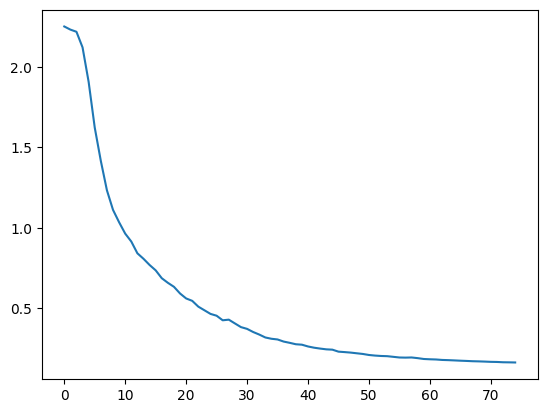

best validation accuracy achieved: 0.781000


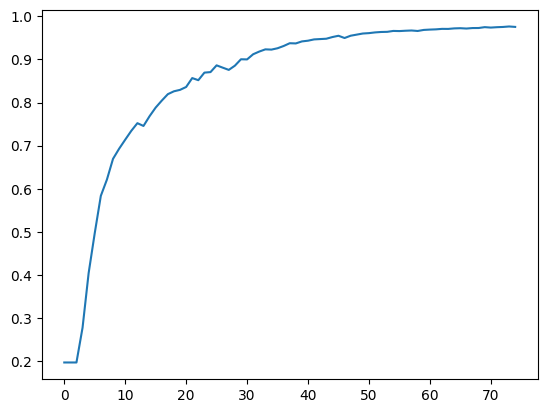

In [ ]:
# Let's train the best one-hidden-layer network we can
import itertools


learning_rates = 2e-1 #15e-2
reg_strength = 1e-7 #1e-5
learning_rate_decay = 0.96 #0.99
hidden_layer_size = 1026 #512
num_epochs = 75 #150
batch_size = 500 #300

best_classifier = None
best_val_accuracy = 0.781000

loss_history = []
train_history = []
val_history = []

# TODO find the best hyperparameters to train the network
# Don't hesitate to add new values to the arrays above, perform experiments, use any tricks you want
# You should expect to get to at least 40% of valudation accuracy
# Save loss/train/history of the best classifier to the variables above


model = TwoLayerNet(n_input = train_X.shape[1], n_output = 10, hidden_layer_size = hidden_layer_size, reg = reg_strength)
dataset = Dataset(train_X, train_y, val_X, val_y)
trainer = Trainer(model, dataset, MomentumSGD(), learning_rate=learning_rates, num_epochs=num_epochs, batch_size=batch_size,
                  learning_rate_decay=learning_rate_decay)

loss_history, train_history, val_history = trainer.fit()
plt.plot(loss_history)
plt.show()
plt.plot(train_history)


print('best validation accuracy achieved: %f' % best_val_accuracy)

In [ ]:
best_classifier = model

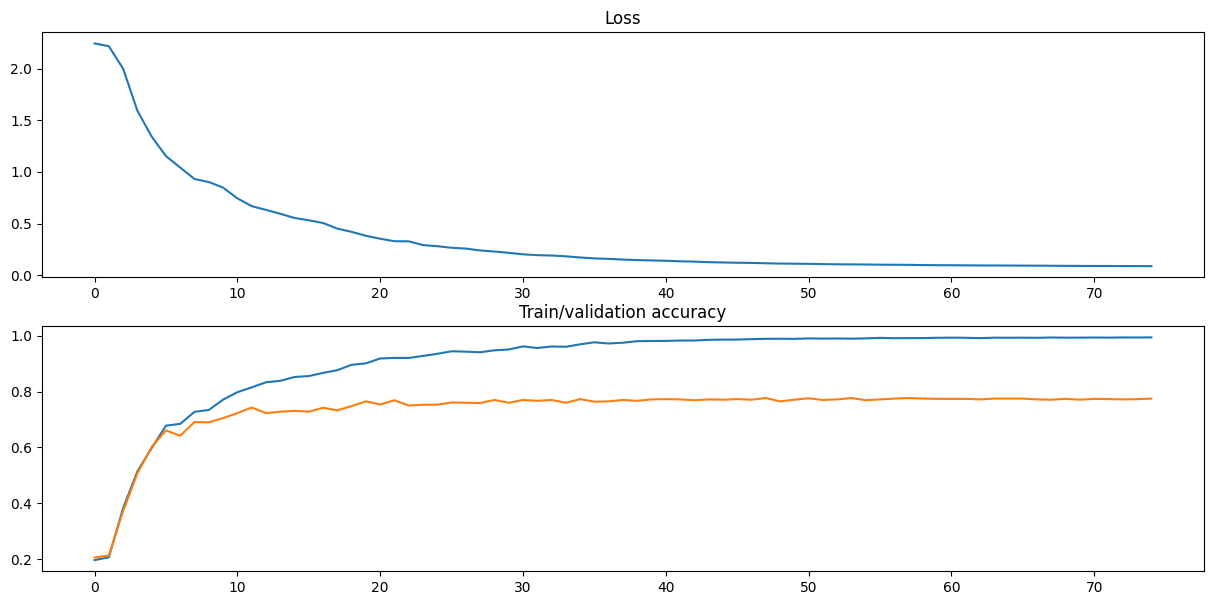

In [ ]:
plt.figure(figsize=(15, 7))
plt.subplot(211)
plt.title("Loss")
plt.plot(loss_history)
plt.subplot(212)
plt.title("Train/validation accuracy")
plt.plot(train_history)
plt.plot(val_history)

# Как обычно, посмотрим, как наша лучшая модель работает на тестовых данных

In [ ]:
test_pred = best_classifier.predict(test_X)
test_accuracy = multiclass_accuracy(test_pred, test_y)
print('Neural net test set accuracy: %f' % (test_accuracy, )) #0.766

Neural net test set accuracy: 0.766000
